In [ ]:
#01_import_libraries
#Importation des bibliothèques nécessaires au projet
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
# Connexion de Google Drive à Google Colab
# Permet d'accéder au dataset stocké dans Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#02_load_dataset
from scipy.io import arff

data = arff.loadarff("Rice_Cammeo_Osmancik.arff")

df = pd.DataFrame(data[0])

df.head()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231.0,525.578979,229.749878,85.093788,0.928882,15617.0,0.572896,b'Cammeo'
1,14656.0,494.311005,206.020065,91.730972,0.895405,15072.0,0.615436,b'Cammeo'
2,14634.0,501.122009,214.106781,87.768288,0.912118,14954.0,0.693259,b'Cammeo'
3,13176.0,458.342987,193.337387,87.448395,0.891861,13368.0,0.640669,b'Cammeo'
4,14688.0,507.166992,211.743378,89.312454,0.906691,15262.0,0.646024,b'Cammeo'


### Chargement du dataset

Le dataset **Rice (Cammeo and Osmancik)** est chargé à partir du fichier `Rice_Cammeo_Osmancik.arff` à l'aide de la fonction `loadarff()`. Les données sont ensuite converties en DataFrame Pandas pour faciliter leur analyse. Enfin, les premières lignes du dataset sont affichées afin de vérifier le bon chargement des données.


In [ ]:
#Si la colonne Class apparait en binaire
df["Class"] = df["Class"].str.decode("utf-8")

### Conversion de la variable cible

La variable **Class** est initialement stockée sous forme binaire (*bytes*) après le chargement du fichier ARFF. Cette étape permet de convertir les valeurs en texte lisible (**Cammeo** et **Osmancik**) afin de faciliter l'analyse et les traitements ultérieurs.


In [ ]:
#Source du dataset
print("""Dataset: Rice(Cammeo and Osmancik)
         Source: UCI Machine Learning Repository)
         Lien: https://archive.ics.uci.edu/datasets/?search=Rice+%28Cammeo+and+Osmancik%29
         Le dataset contient 3810 grains de riz décrits par des caractéristiques morphologiques extraites d'images.""")

Dataset: Rice(Cammeo and Osmancik)
         Source: UCI Machine Learning Repository)
         Lien: https://archive.ics.uci.edu/datasets/?search=Rice+%28Cammeo+and+Osmancik%29
         Le dataset contient 3810 grains de riz décrits par des caractéristiques morphologiques extraites d'images.


### Présentation de la source des données

Cette étape permet d'afficher les informations principales relatives au dataset utilisé dans le projet, notamment son nom, sa source officielle, son lien de téléchargement ainsi qu'une brève description de son contenu. Cela garantit la traçabilité des données et facilite leur identification.


In [ ]:
#03_problem_understanding
print("L'objectif est de construire un modèle capable de prédire automatiquement la variété d'un grain de riz (Cammeo ou Osmancik) à partir de ses caractéristiques morphologiques. Il s'agit d'un problème de classification binaire supervisée.")


L'objectif est de construire un modèle capable de prédire automatiquement la variété d'un grain de riz (Cammeo ou Osmancik) à partir de ses caractéristiques morphologiques. Il s'agit d'un problème de classification binaire supervisée.


### Compréhension du problème

Cette étape permet de définir clairement la problématique étudiée. L'objectif est de prédire la variété d'un grain de riz à partir de ses caractéristiques morphologiques. Il s'agit d'un problème de classification supervisée binaire comportant deux classes : **Cammeo** et **Osmancik**.


In [ ]:
#04_dataset_description
 #Afficher
df.shape

(3810, 8)

### Dimensions du dataset

Cette étape permet d'afficher les dimensions du dataset, c'est-à-dire le nombre d'observations et le nombre de variables disponibles pour l'analyse.



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3810 entries, 0 to 3809
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area               3810 non-null   float64
 1   Perimeter          3810 non-null   float64
 2   Major_Axis_Length  3810 non-null   float64
 3   Minor_Axis_Length  3810 non-null   float64
 4   Eccentricity       3810 non-null   float64
 5   Convex_Area        3810 non-null   float64
 6   Extent             3810 non-null   float64
 7   Class              3810 non-null   object 
dtypes: float64(7), object(1)
memory usage: 238.3+ KB


### Types des variables

Cette étape permet de vérifier le type de chaque variable, le nombre de valeurs non nulles ainsi que la structure générale du dataset.

In [ ]:
df.describe()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent
count,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000
mean,12667.727559,454.239180,188.776222,86.313750,0.886871,12952.496850,0.661934
std,1732.367706,35.597081,17.448679,5.729817,0.020818,1776.972042,0.077239
min,7551.000000,359.100006,145.264465,59.532406,0.777233,7723.000000,0.497413
25%,11370.500000,426.144753,174.353855,82.731695,0.872402,11626.250000,0.598862
50%,12421.500000,448.852493,185.810059,86.434647,0.889050,12706.500000,0.645361
75%,13950.000000,483.683746,203.550438,90.143677,0.902588,14284.000000,0.726562
max,18913.000000,548.445984,239.010498,107.542450,0.948007,19099.000000,0.861050


Les statistiques descriptives fournissent un résumé numérique des variables, notamment la moyenne, l'écart-type, les valeurs minimales et maximales ainsi que les quartiles. Elles permettent de mieux comprendre la distribution des données.

In [ ]:
#Afficher les colonnes
df.columns

Index(['Area', 'Perimeter', 'Major_Axis_Length', 'Minor_Axis_Length',
       'Eccentricity', 'Convex_Area', 'Extent', 'Class'],
      dtype='object')

### Nom des colonnes

Cette étape permet d'afficher la liste des variables présentes dans le dataset. Elle permet de vérifier que les noms des colonnes ont été correctement chargés et qu'ils correspondent à la documentation officielle du dataset. Cette vérification facilite également les étapes d'analyse et de prétraitement des données.

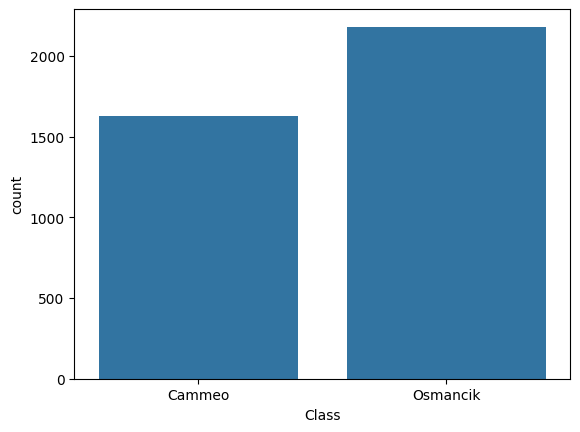

In [ ]:
#05_exploratory_data_analysis
#Répartition des classes
sns.countplot(x="Class", data=df)
plt.show()

### La répatition des classes

Le graphique montre que les deux variétés de riz sont relativement bien représentées dans le dataset. La variété Osmancik est légèrement majoritaire avec 2180 observations contre 1630 pour Cammeo. Ce déséquilibre reste modéré et ne devrait pas avoir un impact significatif sur l'apprentissage des modèles de classification.

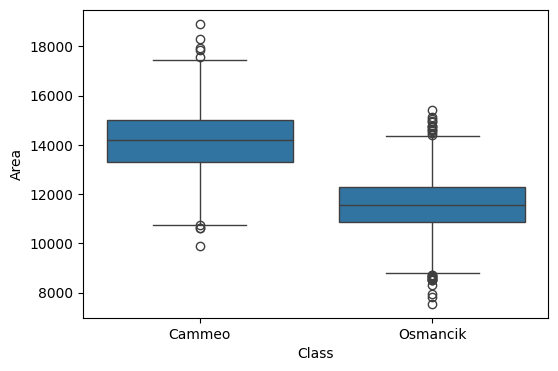

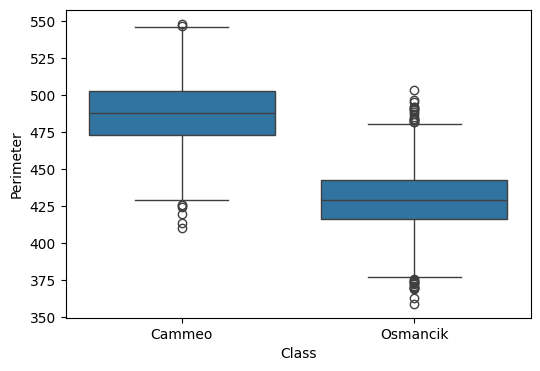

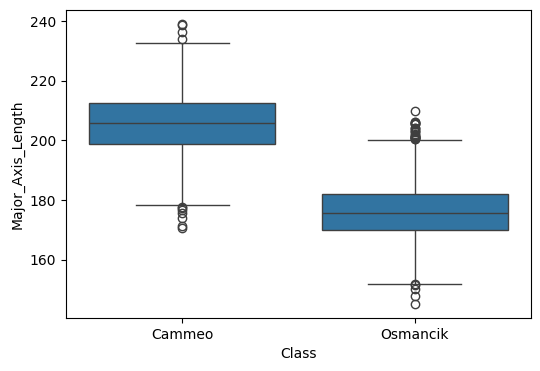

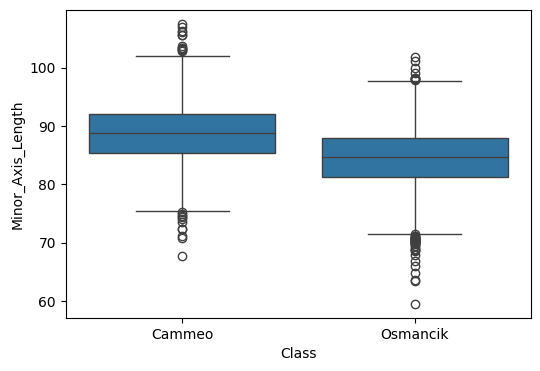

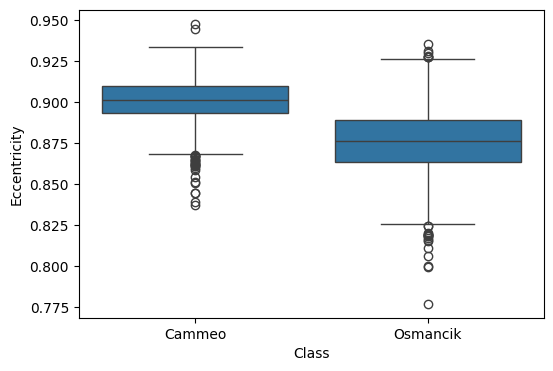

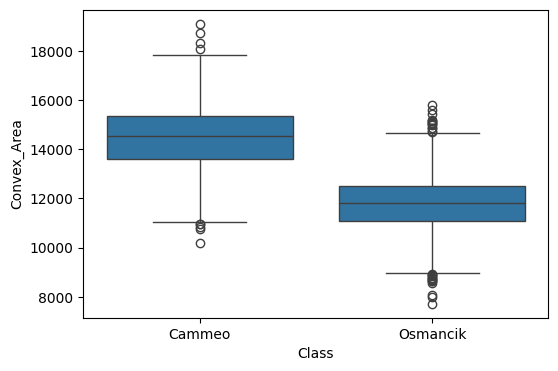

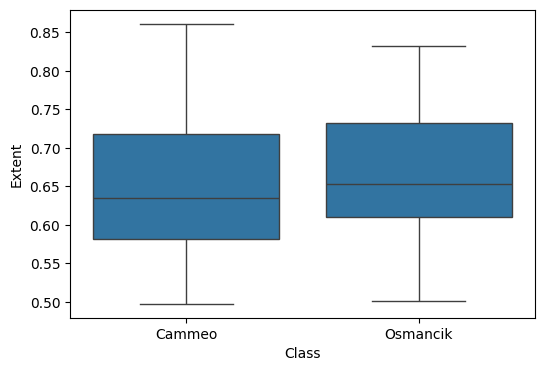

In [ ]:
#visualisations
#Boxplots
for col in df.columns[:-1]:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Class", y=col, data=df)
    plt.show()

### Comparaison des distributions par classe

Cette étape génère des boxplots pour chaque variable numérique du dataset en fonction de la variété de riz. Ces graphiques permettent de comparer les distributions des caractéristiques morphologiques entre les classes **Cammeo** et **Osmancik**, d'observer leur dispersion et de repérer d'éventuelles valeurs atypiques. Cette analyse aide à identifier les variables susceptibles de mieux différencier les deux variétés de riz.


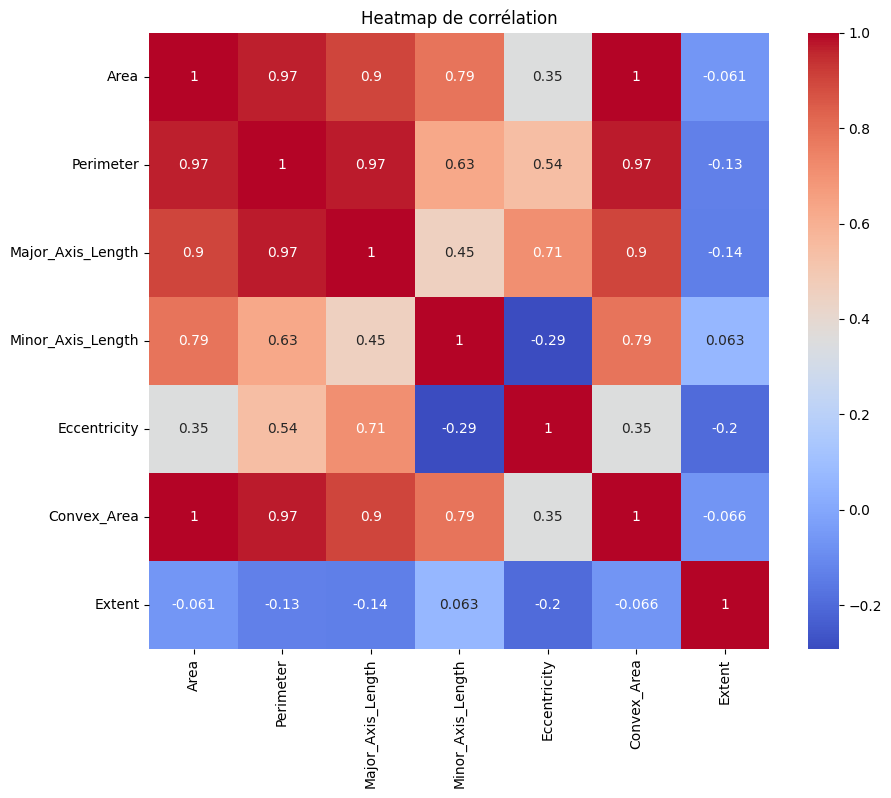

In [ ]:
 #Heatmap de corrélation
plt.figure(figsize=(10,8))

sns.heatmap(
    df.drop("Class", axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Heatmap de corrélation")
plt.show()

### Analyse des corrélations entre les variables

Cette étape permet de visualiser les corrélations entre les différentes variables numériques du dataset à l'aide d'une heatmap. Les coefficients de corrélation indiquent l'intensité et le sens des relations entre les variables. Cette analyse permet d'identifier les caractéristiques fortement liées entre elles et de mieux comprendre la structure des données avant la phase de modélisation.


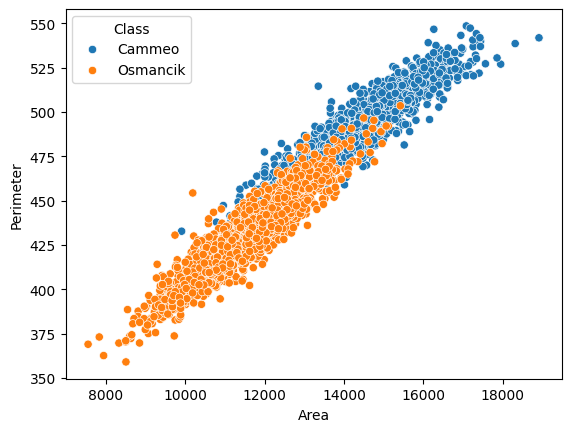

In [ ]:
#Scatter Plot
sns.scatterplot(
    x="Area",
    y="Perimeter",
    hue="Class",
    data=df
)

plt.show()

### Analyse de la relation entre l’aire et le périmètre

Cette visualisation permet d’examiner la relation entre les variables Area et Perimeter tout en distinguant les observations selon leur variété de riz. Le graphique aide à identifier d’éventuelles tendances, regroupements ou séparations entre les classes Cammeo et Osmancik, et à évaluer la capacité de ces caractéristiques morphologiques à différencier les deux variétés.

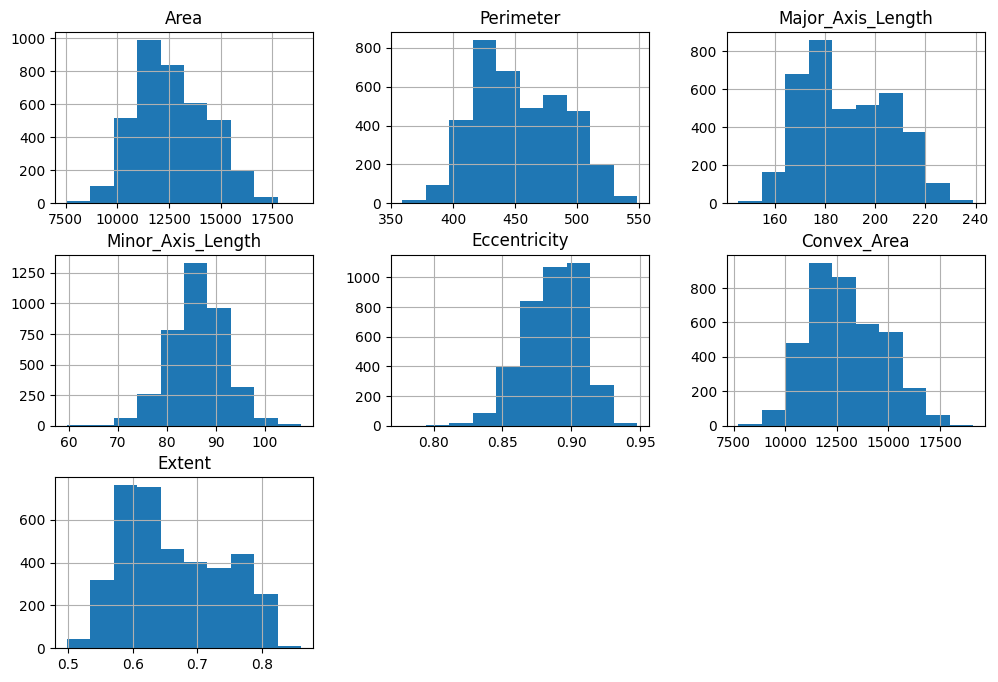

In [ ]:
#Histogrammes des variables numériques
df.hist(figsize=(12,8))
plt.show()

### **Distribution des variables numériques**

 Cette étape permet de visualiser la distribution de l’ensemble des variables numériques du dataset à l’aide d’histogrammes. Ces graphiques facilitent l’analyse de la répartition des données, de leur dispersion, de leur asymétrie éventuelle ainsi que l’identification de valeurs atypiques. Ils permettent également de mieux comprendre les caractéristiques morphologiques des grains de riz avant la phase de modélisation.


In [ ]:
#06_data_quality_and_cleaning
#Valeurs manquantes
df.isnull().sum()

,0
Area,0
Perimeter,0
Major_Axis_Length,0
Minor_Axis_Length,0
Eccentricity,0
Convex_Area,0
Extent,0
Class,0


###  **Vérification des valeurs manquantes**

 Cette étape permet d'identifier la présence éventuelle de valeurs manquantes dans chaque variable du dataset. La détection de ces valeurs est essentielle pour garantir la qualité des données et éviter qu'elles n'affectent les résultats de l'analyse ou les performances des modèles de classification.

In [ ]:
#Doublons
df.duplicated().sum()

np.int64(0)

###  **Vérification des doublons**

 Cette étape permet de détecter la présence d'observations dupliquées dans le dataset. L'identification des doublons est importante afin d'éviter une surreprésentation de certaines données, susceptible d'influencer les résultats de l'analyse et les performances des modèles de classification.

In [ ]:
#Types de données
df.dtypes

,0
Area,float64
Perimeter,float64
Major_Axis_Length,float64
Minor_Axis_Length,float64
Eccentricity,float64
Convex_Area,float64
Extent,float64
Class,object


###  **Analyse des types de variables**

 Cette étape permet de vérifier que les variables descriptives sont de type numérique (**float64**) et que la variable cible **Class** est de type catégoriel (**object**), ce qui est conforme à la nature du problème de classification étudié.


In [ ]:
#07_preprocessing
#encodage
encoder = LabelEncoder()

df["Class"] = encoder.fit_transform(df["Class"])

###  **Encodage de la variable cible**

 Cette étape consiste à transformer la variable cible **Class**, initialement sous forme textuelle (*Cammeo* et *Osmancik*), en valeurs numériques à l'aide de **LabelEncoder**. Cet encodage est nécessaire pour permettre aux algorithmes de Machine Learning de traiter correctement les données.

In [ ]:
#Séparation X et y
X = df.drop("Class", axis=1)

y = df["Class"]

### Séparation des données d’entraînement et de test

Cette étape consiste à diviser le dataset en deux ensembles : un ensemble d’entraînement (80 %) utilisé pour apprendre les modèles et un ensemble de test (20 %) utilisé pour évaluer leurs performances. L’option stratify=y permet de conserver la même proportion des classes dans les deux ensembles afin d’obtenir une évaluation plus fiable.


In [ ]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

### Séparation des données d’entraînement et de test

Cette étape consiste à diviser le dataset en deux ensembles : un ensemble d’entraînement (80 %) utilisé pour apprendre les modèles et un ensemble de test (20 %) utilisé pour évaluer leurs performances. L’option stratify=y permet de conserver la même proportion des classes dans les deux ensembles afin d’obtenir une évaluation plus fiable.

In [ ]:
#Standardisation
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

 **Standardisation des variables**

 Cette étape consiste à normaliser les variables numériques à l’aide de **StandardScaler** afin de leur donner une moyenne nulle et un écart-type égal à 1. La standardisation est particulièrement importante pour les modèles sensibles à l’échelle des données, tels que **KNN**, **SVM** et la **Régression Logistique**, car elle améliore leur performance et leur stabilité.


In [ ]:
#08_modeling_or_clustering
#Logistic Regression
lr = LogisticRegression()

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)


### Modélisation avec la Régression Logistique

Cette étape consiste à entraîner un modèle de Régression Logistique sur les données d'entraînement standardisées. Ce modèle est couramment utilisé pour les problèmes de classification binaire. Une fois entraîné, il est utilisé pour prédire la classe des observations de l'ensemble de test afin d'évaluer ses performances.

In [ ]:
#KNN
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

### Modélisation avec l’algorithme K-Nearest Neighbors (KNN)

Consiste à entraîner un modèle **KNN** en utilisant les données d'entraînement standardisées. Cet algorithme classe chaque observation en fonction des **k plus proches voisins**, ici **k = 5**. Le modèle est ensuite utilisé pour prédire la variété des grains de riz de l'ensemble de test afin d'évaluer ses performances.

In [ ]:
#SVM linéaire
from sklearn.svm import SVC

svm = SVC(kernel='linear')

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

###  **Modélisation avec la Machine à Vecteurs de Support (SVM)**

SVM consiste à entraîner un modèle **SVM linéaire** sur les données d'entraînement standardisées. Cet algorithme cherche à déterminer l'hyperplan qui sépare au mieux les deux classes de riz tout en maximisant la marge de séparation. Le modèle est ensuite utilisé pour prédire la variété des grains de riz de l'ensemble de test afin d'évaluer ses performances.


In [ ]:
print(svm)

SVC(kernel='linear')


### Vérification de la configuration du modèle SVM

Cette étape permet d'afficher les paramètres du modèle SVM utilisé afin de vérifier que le noyau linéaire a bien été pris en compte avant l'évaluation des performances.

In [ ]:
#Random Forest
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

###  **Modélisation avec Random Forest**

 Cette étape consiste à entraîner un modèle **Random Forest** sur les données d'entraînement. Cet algorithme repose sur un ensemble d'arbres de décision dont les prédictions sont combinées pour améliorer la précision et la capacité de généralisation. Le modèle est ensuite utilisé pour prédire la variété des grains de riz de l'ensemble de test afin d'évaluer ses performances.


In [ ]:
#09_evaluation
#Fonction d'évaluation

def evaluate_model(y_true, y_pred):

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision :", precision_score(y_true, y_pred))
    print("Recall :", recall_score(y_true, y_pred))
    print("F1 :", f1_score(y_true, y_pred))

    print(classification_report(y_true, y_pred))

###  **Modélisation avec Random Forest**

 Cette étape consiste à entraîner un modèle **Random Forest** sur les données d'entraînement. Cet algorithme repose sur un ensemble d'arbres de décision dont les prédictions sont combinées pour améliorer la précision et la capacité de généralisation. Le modèle est ensuite utilisé pour prédire la variété des grains de riz de l'ensemble de test afin d'évaluer ses performances.


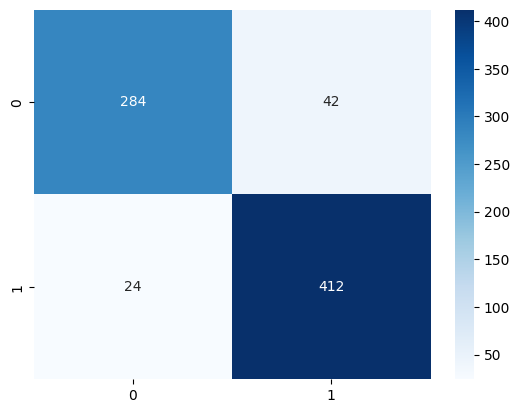

In [ ]:
#Matrice de confusion
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.show()

###  **Matrice de confusion du modèle Random Forest**

 Cette étape permet de visualiser les performances du modèle à l'aide d'une matrice de confusion. Ce graphique présente le nombre de prédictions correctes et incorrectes pour chaque classe, ce qui facilite l'analyse détaillée des erreurs de classification et l'évaluation de la capacité du modèle à distinguer les variétés **Cammeo** et **Osmancik**.


In [ ]:
# Tableau comparatif
metrics = {

    'Logistic Regression': {
        'Accuracy': accuracy_score(y_test, y_pred_lr),
        'Precision': precision_score(y_test, y_pred_lr),
        'Recall': recall_score(y_test, y_pred_lr),
        'F1-Score': f1_score(y_test, y_pred_lr)
    },
    'KNN': {
        'Accuracy': accuracy_score(y_test, y_pred_knn),
        'Precision': precision_score(y_test, y_pred_knn),
        'Recall': recall_score(y_test, y_pred_knn),
        'F1-Score': f1_score(y_test, y_pred_knn)
    },
    'SVM': {
        'Accuracy': accuracy_score(y_test, y_pred_svm),
        'Precision': precision_score(y_test, y_pred_svm),
        'Recall': recall_score(y_test, y_pred_svm),
        'F1-Score': f1_score(y_test, y_pred_svm)
    },
    'Random Forest': {
        'Accuracy': accuracy_score(y_test, y_pred_rf),
        'Precision': precision_score(y_test, y_pred_rf),
        'Recall': recall_score(y_test, y_pred_rf),
        'F1-Score': f1_score(y_test, y_pred_rf)
    }
}

results = pd.DataFrame(metrics).T
results.round(4)

,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.9160,0.9152,0.9404,0.9276
KNN,0.9094,0.9124,0.9312,0.9217
SVM,0.9186,0.9174,0.9427,0.9299
Random Forest,0.9134,0.9075,0.9450,0.9258


### > **Comparaison des performances des modèles**

 Cette étape permet de calculer et de comparer les principales métriques d'évaluation (**Accuracy**, **Precision**, **Recall** et **F1-Score**) pour les quatre modèles testés : **Logistic Regression**, **KNN**, **SVM** et **Random Forest**. Le tableau obtenu facilite l'identification du modèle le plus performant pour la classification des variétés de riz.


In [ ]:
#10_interpretation_and_limits
#Importance des variables
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
1,Perimeter,0.269484
2,Major_Axis_Length,0.266408
0,Area,0.173786
5,Convex_Area,0.132493
4,Eccentricity,0.083157
3,Minor_Axis_Length,0.042897
6,Extent,0.031776


###  **Importance des variables**

 Cette étape permet d'identifier les variables les plus influentes dans les prédictions du modèle **Random Forest**. Le score d'importance attribué à chaque caractéristique mesure sa contribution à la classification des variétés de riz. Cette analyse facilite l'interprétation du modèle et met en évidence les caractéristiques morphologiques les plus discriminantes entre **Cammeo** et **Osmancik**.


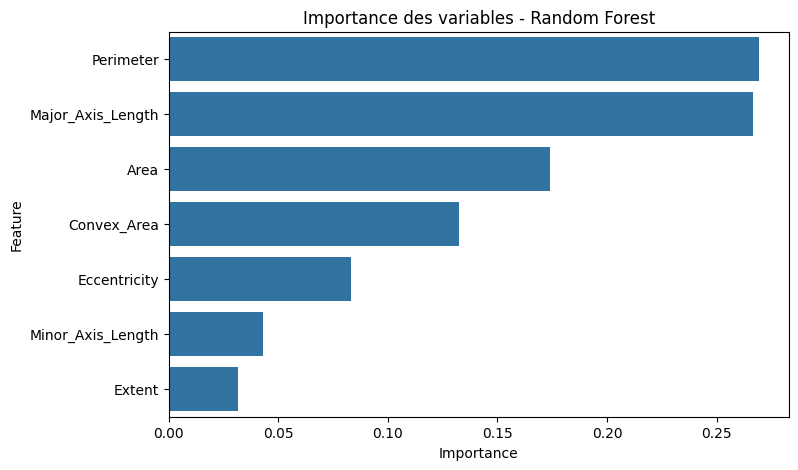

In [ ]:
#Graphique d'importance
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Importance des variables - Random Forest")

plt.show()

###  **Visualisation de l’importance des variables**

Cette étape permet de représenter graphiquement l’importance des différentes caractéristiques utilisées par le modèle **Random Forest**. Ce graphique facilite l’identification des variables les plus influentes dans la prédiction de la variété des grains de riz et contribue à une meilleure interprétation des résultats obtenus.


In [ ]:
## Interprétation des résultats

print("""L'analyse de l'importance des variables montre que les caractéristiques les plus importantes pour distinguer les variétés de riz Cammeo et Osmancik sont :

- Perimeter
- Major_Axis_Length
- Area
- Convex_Area
- Eccentricity

Ces variables contribuent davantage aux décisions du modèle Random Forest.

Les variables Minor_Axis_Length et Extent ont une influence plus faible sur la classification.

Les résultats montrent que les caractéristiques morphologiques permettent de distinguer efficacement les deux variétés de riz.""")

L'analyse de l'importance des variables montre que les caractéristiques les plus importantes pour distinguer les variétés de riz Cammeo et Osmancik sont :

- Perimeter
- Major_Axis_Length
- Area
- Convex_Area
- Eccentricity

Ces variables contribuent davantage aux décisions du modèle Random Forest.

Les variables Minor_Axis_Length et Extent ont une influence plus faible sur la classification.

Les résultats montrent que les caractéristiques morphologiques permettent de distinguer efficacement les deux variétés de riz.


In [ ]:
# Analyse du meilleur modèle

print("""Après comparaison des modèles Logistic Regression, KNN, SVM et Random Forest, le modèle SVM a obtenu les meilleures performances avec un F1-score de 0.9299.

Le modèle SVM présente également les meilleurs scores d'Accuracy (0.9186) et de Precision (0.9174), ce qui montre sa capacité à distinguer efficacement les variétés de riz Cammeo et Osmancik.

Le modèle SVM est donc retenu comme le modèle le plus performant pour cette tâche de classification.""")

Après comparaison des modèles Logistic Regression, KNN, SVM et Random Forest, le modèle SVM a obtenu les meilleures performances avec un F1-score de 0.9299.

Le modèle SVM présente également les meilleurs scores d'Accuracy (0.9186) et de Precision (0.9174), ce qui montre sa capacité à distinguer efficacement les variétés de riz Cammeo et Osmancik.

Le modèle SVM est donc retenu comme le modèle le plus performant pour cette tâche de classification.


In [ ]:
# Limites

print("""Le dataset contient uniquement deux variétés de riz : Cammeo et Osmancik.

Les résultats obtenus ne peuvent donc pas être généralisés à toutes les variétés de riz.

De plus, les performances du modèle peuvent varier sur d'autres jeux de données ou dans des conditions d'acquisition différentes.""")

Le dataset contient uniquement deux variétés de riz : Cammeo et Osmancik.

Les résultats obtenus ne peuvent donc pas être généralisés à toutes les variétés de riz.

De plus, les performances du modèle peuvent varier sur d'autres jeux de données ou dans des conditions d'acquisition différentes.


In [ ]:
# Pistes d'amélioration

print("""Plusieurs améliorations peuvent être envisagées :

- Tester d'autres algorithmes de classification.
- Optimiser les hyperparamètres des modèles.
- Utiliser davantage de données d'entraînement.
- Ajouter de nouvelles caractéristiques morphologiques.
- Réaliser une validation croisée plus approfondie.""")

Plusieurs améliorations peuvent être envisagées :

- Tester d'autres algorithmes de classification.
- Optimiser les hyperparamètres des modèles.
- Utiliser davantage de données d'entraînement.
- Ajouter de nouvelles caractéristiques morphologiques.
- Réaliser une validation croisée plus approfondie.
